# 92 성능 테스트 및 비교 검증 — 결과 노트북

수치 원본은 `RESULTS.md`(이 폴더). 이 노트북은 그 표를 **출력 그대로 보면서 설명**하기 위한 것이라 출력을 남긴 채
커밋한다. 입력은 `evaluate.py`·`compare_families.py`가 저장한 parquet이고, 다시 계산하지 않는다.

| 절 | 질문 | 입력 |
| --- | --- | --- |
| 1 | 열차·5분 단위로 내려 보여주는 것이 30분 그대로보다 나은가 | `sim_eval_base.parquet` |
| 2 | 생성기 가정(모양 편차·도착 혼합·운행 편차)에 결론이 흔들리나 | `sim_eval_grid.parquet` |
| 3 | 실시간 배차 정보의 가치는 얼마인가 (E-5) | 1의 oracle 행 |
| 4 | Chronos zero-shot·LLM이 90의 LightGBM보다 나은가 | `family_compare_*.parquet` |
| 5 | 열차별 추정이 실제로 어떻게 보이나 — 강남 외선 한 슬롯 | `interim/sim/*.parquet` |

In [1]:
import os
import sys
from pathlib import Path

if Path.cwd().name != "AI":
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "app").is_dir() and (cand / "DATA_ENGINE").is_dir():
            os.chdir(cand)
            break
sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from DATA_ENGINE.eda import figstyle as fs
from DATA_ENGINE.eda import report_figures as rf

fs.apply(inline=True)
pd.set_option("display.width", 160)
inp = rf.Inputs()
V = Path("data/CROWD/interim/validation")
base = pd.read_parquet(V / "sim_eval_base.parquet")
grid = pd.read_parquet(V / "sim_eval_grid.parquet")
print("기본 표", base.shape, "| 격자", grid.shape)

기본 표 (48, 18) | 격자 (216, 18)


## 1. 열차 단위 — 30분 그대로 vs 간격 비례 vs 도착 혼합

**결론** — 도착 혼합(92)의 등급 일치율은 30분 그대로보다 +3.8%p(편차 없음) / +3.2(지연) / +3.6(결행), MAE는
3.6 → 1.4%p. 판정 기준(+3%p, 편차 시나리오에서도 열등하지 않음)을 넘는다. 다만 "정보가 있는 셀"이 6~7%라
열차 열 대 중 아홉 대는 30분 평균과 같은 등급이다 — 표출은 평균과 다를 때만 강조하는 형태가 맞다.

In [2]:
cols = ["MAE_%p", "RMSE_%p", "등급일치_%", "정보셀_%", "정보셀_적중_%", "phantom_ratio"]
t = base[base["unit"] == "train"].groupby(["cfg_scenario", "predictor"], sort=False)[cols].mean().round(2)
flat = t.xs("slot_flat", level="predictor")["등급일치_%"]
t["Δ일치_vs_flat"] = (t["등급일치_%"] - t.index.get_level_values(0).map(flat)).round(2)
t

MAE_%p  RMSE_%p  등급일치_%  정보셀_%  정보셀_적중_%  phantom_ratio  Δ일치_vs_flat
cfg_scenario predictor                                                                      
none         slot_flat    3.62     6.34   94.10   5.90      0.00           0.00         0.00
             prop         1.61     2.65   97.66   5.90     78.18           0.00         3.56
             mix          1.42     1.97   97.91   5.90     76.24           0.00         3.81
             oracle_tt    1.42     1.97   97.91   5.90     76.24           0.00         3.81
delay        slot_flat    4.76     9.54   92.48   7.42      1.77           0.00         0.00
             prop         3.06     7.52   95.46   7.42     58.38           0.00         2.98
             mix          2.88     7.30   95.68   7.42     56.72           0.00         3.20
             oracle_tt    1.42     1.98   97.94   7.42     81.64           0.00         5.46
skip         slot_flat    3.95     7.80   93.65   6.24      5.76           0.01         0.00
             prop         2.05     5.40   97.02   6.24     74.66           0.01         3.37
             mix          1.86     5.10   97.26   6.24     72.68           0.01         3.61
             oracle_tt    1.43     2.00   97.93   6.24     77.93           0.00         4.28

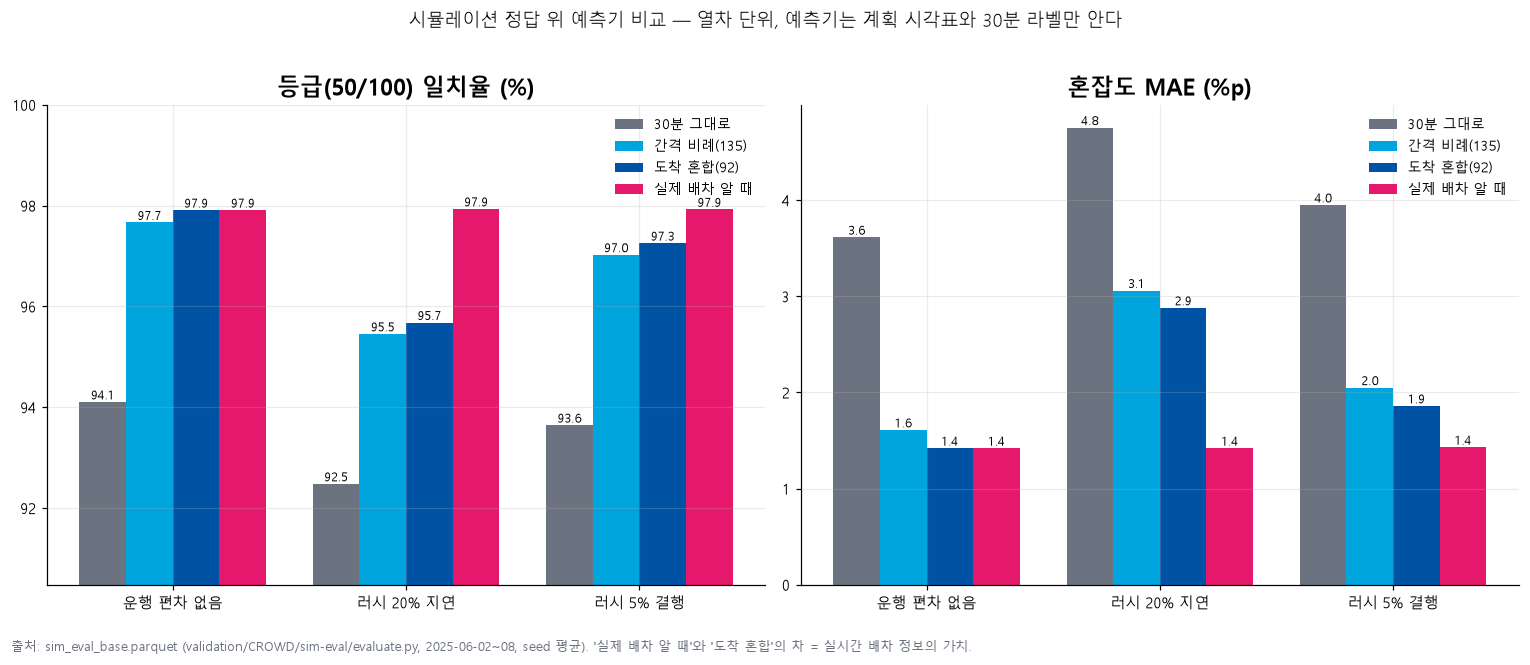

In [3]:
rf.fig_sim_predictor_comparison(inp);          # unit="bin5" 로 5분 빈 단위

### 5분 빈 단위는 열차 단위보다 이득이 작다

열차 도착이 계획과 어긋나면(지연) 실제 빈과 예측 빈이 갈려 손해를 본다. +2.8~3.1%p. 5분 빈은 만들지 않고
열차 단위(또는 30분)로 간다.

In [4]:
b = base[base["unit"] == "bin5"].groupby(["cfg_scenario", "predictor"], sort=False)[cols[:3]].mean().round(2)
b.unstack("predictor")["등급일치_%"][["slot_flat", "prop", "mix", "oracle_tt"]]

predictor,slot_flat,prop,mix,oracle_tt
cfg_scenario,,,,
none,94.82,97.71,97.96,97.96
delay,94.01,96.52,96.76,97.98
skip,94.34,97.10,97.34,97.98


## 2. 생성기 가정 민감도

**결론** — 27셀 전부 양수(+2.6 ~ +4.2%p), 부호가 바뀌는 셀이 없다. +3%p 아래는 지연 시나리오에서 생성기 도착 혼합이
5-10분이거나 모양 편차 σ=0.08일 때 5셀. 결론은 가정에 강건하되, 절대 수치는 "30분 라벨이 맞다"는 전제 위의 값.

C:\Users\SSAFY\miniforge3\envs\SUMGIL\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  func(*args, **kwargs)
C:\Users\SSAFY\miniforge3\envs\SUMGIL\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


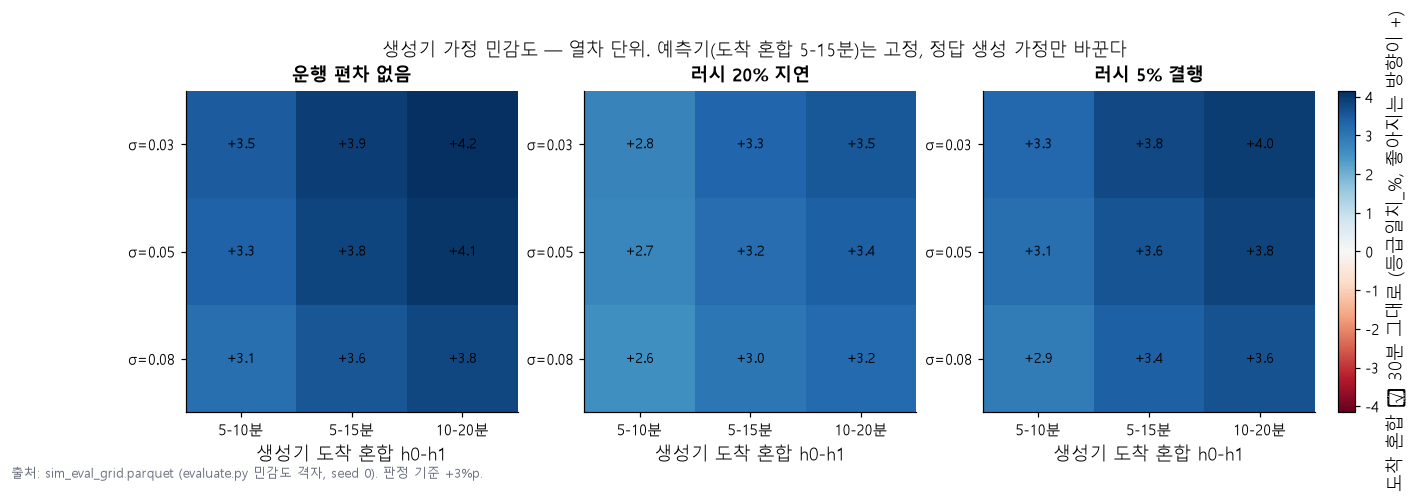

In [5]:
rf.fig_sim_sensitivity_grid(inp);              # metric="MAE_%p" 로 MAE 차이

## 3. 실시간 배차 정보의 가치 (팀 논의 E-5)

`oracle_tt`는 편차가 반영된 실제 시각표를 안다(모양 편차·Poisson은 모른다). 계획 시각표만 아는 `mix`와의 차이가
실시간 도착정보를 연결했을 때 얻을 수 있는 상한이다.

**결론** — 지연 시나리오에서 등급 일치 +2.3%p, MAE 2.88 → 1.42%p(절반). 결행에서는 +0.7%p. 운행 편차가 없는
날에는 0. 실시간 배차 연결은 "지연이 잦은 날의 품질"을 위한 것이고, 그 크기는 30분→열차 전환(+3.2)의 70% 수준.

In [6]:
o = t.reset_index()
o = o[o["predictor"].isin(["mix", "oracle_tt"])].pivot(index="cfg_scenario", columns="predictor", values=["등급일치_%", "MAE_%p"])
o["Δ일치_oracle−mix"] = (o[("등급일치_%", "oracle_tt")] - o[("등급일치_%", "mix")]).round(2)
o["MAE_mix/oracle"] = (o[("MAE_%p", "mix")] / o[("MAE_%p", "oracle_tt")]).round(2)
o

등급일치_%           MAE_%p           Δ일치_oracle−mix MAE_mix/oracle
predictor       mix oracle_tt    mix oracle_tt                              
cfg_scenario                                                                
delay         95.68     97.94   2.88      1.42           2.26           2.03
none          97.91     97.91   1.42      1.42           0.00           1.00
skip          97.26     97.93   1.86      1.43           0.67           1.30

## 4. 모델 계열 비교 — lookup+LightGBM vs Chronos zero-shot (vs LLM)

같은 표본(역 50 × 2025년 30일 × 20슬롯 × 2타깃), 같은 D−1 조건. 채택 기준: LightGBM 대비 RMSE·MAE **둘 다** 2%p 이상.
LLM은 `CROWD_LLM_API_KEY`가 없어 프롬프트 표본(`family_compare_llm_prompts.json`)만 저장 — 미완.

In [7]:
fm = pd.read_parquet(V / "family_compare_metrics.parquet")
fm

,target,family,RMSE,MAE,MAPE_%,RMSE_개선율_%,MAE_개선율_%,n
0,boarding,lookup,271.2,99.3,14.0,0.0,0.0,30000
1,boarding,lightgbm,208.2,73.4,14.3,23.2,26.1,30000
2,boarding,chronos,419.7,136.8,47.9,-54.8,-37.8,30000
3,boarding,chronos_resid,209.3,83.0,19.1,22.8,16.4,30000
4,alighting,lookup,263.0,102.3,14.4,0.0,0.0,30000
5,alighting,lightgbm,194.5,76.0,12.9,26.0,25.7,30000
6,alighting,chronos,453.2,141.8,38.2,-72.3,-38.7,30000
7,alighting,chronos_resid,198.1,85.5,15.8,24.7,16.4,30000


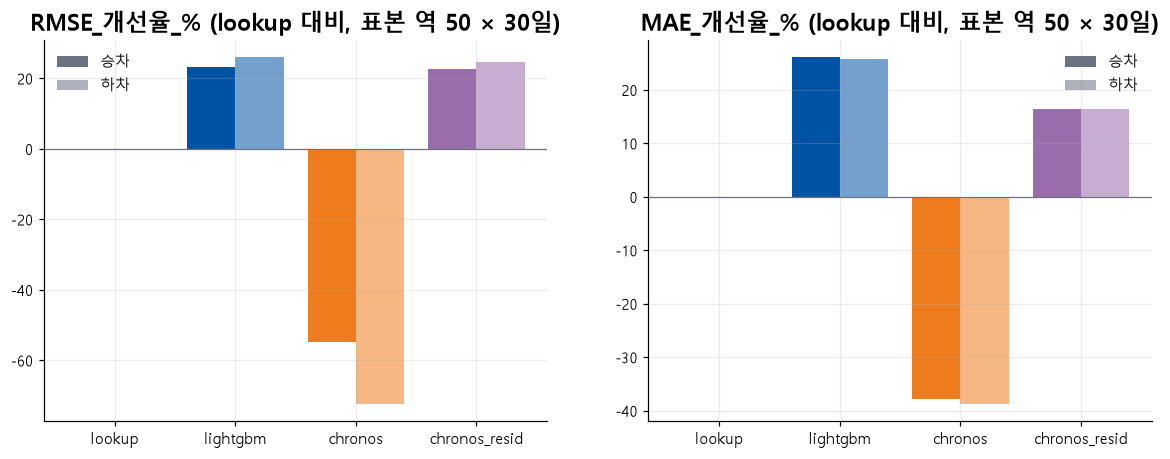

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
order = [f for f in ["lookup", "lightgbm", "chronos", "chronos_resid"] if f in set(fm["family"])]
colors = {"lookup": fs.COLOR_BASELINE, "lightgbm": fs.COLOR_MODEL, "chronos": fs.COLOR_REALTIME, "chronos_resid": fs.LINE_COLORS["5호선"]}
for ax, metric in zip(axes, ("RMSE_개선율_%", "MAE_개선율_%")):
    for j, tgt in enumerate(("boarding", "alighting")):
        vals = [fm[(fm["family"] == f) & (fm["target"] == tgt)][metric].iloc[0] for f in order]
        ax.bar(np.arange(len(order)) + (0.2 if j else -0.2), vals, width=0.4,
               color=[colors[f] for f in order], alpha=1.0 if j == 0 else 0.55, label="승차" if j == 0 else "하차")
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order)
    ax.axhline(0, color=fs.PALETTE_NEUTRAL[1], lw=0.8)
    ax.set_title(f"{metric} (lookup 대비, 표본 역 50 × 30일)")
    ax.legend(frameon=False)
plt.show()

## 5. 열차별 추정이 실제로 어떻게 보이나 — 강남 외선 08시대, 시뮬레이션 정답 vs 예측

시뮬레이션 정답(seed 0, 편차 없음)과 도착 혼합 예측을 같은 슬롯에서 겹쳐 본다. 정답은 Poisson·모양 편차로
흔들리고 예측은 매끈하다 — 등급이 갈리는 열차가 "정보셀"이다.

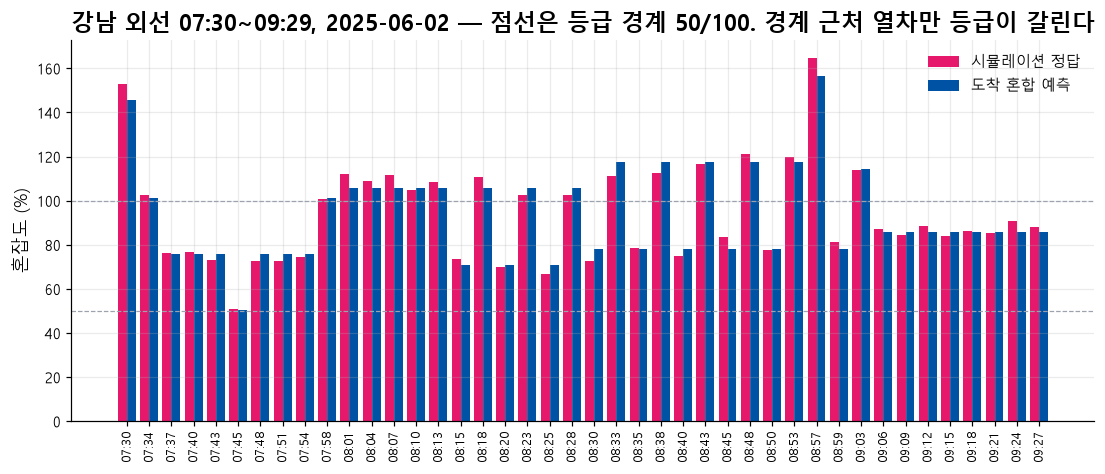

,arrival_time,headway_true,congestion_true,pred_pct,등급_정답,등급_예측
0,07:30:00,6.0,153.0,145.4,2,2
1,07:34:00,4.0,102.8,101.4,2,2
2,07:37:00,3.0,76.5,76.0,1,1
3,07:40:00,3.0,76.7,76.0,1,1
4,07:43:00,3.0,73.0,76.0,1,1
5,07:45:30,2.0,50.9,50.7,1,1
6,07:48:30,3.0,72.8,76.0,1,1
7,07:51:30,3.0,72.6,76.0,1,1
8,07:54:30,3.0,74.4,76.0,1,1
9,07:58:00,4.0,100.9,101.4,2,2


In [9]:
from app.CROWD.pipeline.disaggregate import allocate_to_trains
from DATA_ENGINE.eda.build_load_by_train import prepare_inputs

truth = pd.read_parquet("data/CROWD/interim/sim/sim_truth_20250602_20250608_none_seed0.parquet")
slot_loads, tt, _, _ = prepare_inputs(pd.Timestamp("2025-06-02"), pd.Timestamp("2025-06-02"))
pred = allocate_to_trains(slot_loads, tt, mix_h0=5, mix_h1=15)
pred["pred_pct"] = pred["load_est"] / pred["train_capacity"] * 100

sel = {"station_no": 222, "direction": "외선", "date": pd.Timestamp("2025-06-02")}
slots = ["07:30", "08:00", "08:30", "09:00"]
tr = truth[(truth.station_no == sel["station_no"]) & (truth.direction == sel["direction"]) & (truth.date == sel["date"]) & truth.time_slot_30min.isin(slots)]
pr = pred[(pred.station_no == sel["station_no"]) & (pred.direction == sel["direction"]) & (pred.date == sel["date"]) & pred.time_slot_30min.isin(slots)]
m = tr.merge(pr[["train_id", "arrival_time", "pred_pct"]], on=["train_id", "arrival_time"]).sort_values("arr_min_true")
fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(m))
ax.bar(x - 0.2, m["congestion_true"], width=0.4, color=fs.COLOR_ACCENT, label="시뮬레이션 정답")
ax.bar(x + 0.2, m["pred_pct"], width=0.4, color=fs.COLOR_MODEL, label="도착 혼합 예측")
for y in (50, 100):
    ax.axhline(y, color=fs.PALETTE_NEUTRAL[2], ls="--", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([t[:5] for t in m["arrival_time"]], rotation=90, fontsize=8)
ax.set_ylabel("혼잡도 (%)"); ax.legend(frameon=False)
ax.set_title("강남 외선 07:30~09:29, 2025-06-02 — 점선은 등급 경계 50/100. 경계 근처 열차만 등급이 갈린다")
plt.show()
(m[["arrival_time", "headway_true", "congestion_true", "pred_pct"]].assign(
    등급_정답=lambda d: np.searchsorted([50, 100], d.congestion_true), 등급_예측=lambda d: np.searchsorted([50, 100], d.pred_pct)
).round(1).head(12))

---
**다음.** (1) 배분 기본값을 도착 혼합(5-15분)으로 — 91 API 출력 형식 불변. (2) 열차별 표출은 "30분 평균과 등급이
다른 열차"를 강조하는 형태로 FE와 협의. (3) 실시간 도착정보(OA-12764) 연결은 지연일 품질용 — 91 잔여. (4) LLM 비교는
키 확보 후 같은 표본으로.